In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from process_census_data import prepare_census_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
train_x, val_x, test_x, train_y, val_y, test_y = prepare_census_data(
    random_state=99,
    split_validation=True,
    rebalance=True,
 )

train_x.head()

,class of worker_ Federal government,class of worker_ Local government,class of worker_ Never worked,class of worker_ Not in universe,class of worker_ Private,class of worker_ Self-employed-incorporated,class of worker_ Self-employed-not incorporated,class of worker_ State government,class of worker_ Without pay,enroll in edu inst last wk_ College or university,...,num persons worked for employer,weeks worked in year,education-num,member of a labor union,live in this house 1 year ago,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,year,sex
88942,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1,0,0,-1,0,1,0
121916,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,52.0,14.0,-1,-1,0,-1,-1,0,1
18744,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1,-1,0,-1,0,0,0
33098,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,52.0,2.0,-1,1,0,-1,-1,1,1
125779,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,-1,-1,0,-1,-1,0,1


Get the data in tensor format

In [3]:
train_x_tensor = torch.tensor(train_x.to_numpy(), dtype=torch.float32)
val_x_tensor = torch.tensor(val_x.to_numpy(), dtype=torch.float32)
test_x_tensor = torch.tensor(test_x.to_numpy(), dtype=torch.float32)
train_y_tensor = torch.tensor(train_y.to_numpy(), dtype=torch.float32).unsqueeze(1)
val_y_tensor = torch.tensor(val_y.to_numpy(), dtype=torch.float32).unsqueeze(1)
test_y_tensor = torch.tensor(test_y.to_numpy(), dtype=torch.float32).unsqueeze(1)

Normalize the data

In [4]:
train_mean = train_x_tensor.mean(dim=0, keepdim=True)
train_std = train_x_tensor.std(dim=0, keepdim=True)
train_std = torch.where(train_std == 0, torch.ones_like(train_std), train_std)

train_x_tensor = (train_x_tensor - train_mean) / train_std
val_x_tensor = (val_x_tensor - train_mean) / train_std
test_x_tensor = (test_x_tensor - train_mean) / train_std

Make the dataloaders

In [5]:
train_loader = DataLoader(
    TensorDataset(train_x_tensor, train_y_tensor),
    batch_size=512,
    shuffle=True,
 )
val_loader = DataLoader(TensorDataset(val_x_tensor, val_y_tensor), batch_size=1024)
test_loader = DataLoader(TensorDataset(test_x_tensor, test_y_tensor), batch_size=1024)

Define a simple network

In [6]:
class BasicNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.input_size = input_size
        self.num_classes = num_classes

        self.linear_1 = nn.Linear(input_size, 5)
        self.linear_2 = nn.Linear(5, num_classes)

    def forward(self, x):
        x = nn.ReLU()(self.linear_1(x))
        x = nn.Sigmoid()(self.linear_2(x))

        return x

Inspect the model

After defining a model, it is useful to print its layers, inspect parameter shapes, and count how many trainable parameters it has.

In [7]:
inspection_model = BasicNN(input_size=train_x_tensor.shape[1], num_classes=1)
print(inspection_model)

for name, parameter in inspection_model.named_parameters():
    print(f"{name}: shape={tuple(parameter.shape)}, trainable={parameter.requires_grad}")

sum(parameter.numel() for parameter in inspection_model.parameters() if parameter.requires_grad)

BasicNN(
  (linear_1): Linear(in_features=126, out_features=5, bias=True)
  (linear_2): Linear(in_features=5, out_features=1, bias=True)
)
linear_1.weight: shape=(5, 126), trainable=True
linear_1.bias: shape=(5,), trainable=True
linear_2.weight: shape=(1, 5), trainable=True
linear_2.bias: shape=(1,), trainable=True


641

Define an evaluation function

In [8]:
def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            predictions = model(features)
            all_predictions.append(predictions)
            all_targets.append(targets)

    y_true = torch.cat(all_targets).squeeze(1).numpy()
    y_pred = torch.cat(all_predictions).squeeze(1).numpy()
    y_pred = (y_pred >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

Define the training function

In [9]:
def train_model(model, train_loader, val_loader, device, epochs=12, learning_rate=1e-3):
    torch.manual_seed(99)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCEWithLogitsLoss()

    history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(features)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)

        validation_metrics = evaluate_model(model, val_loader, device)
        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": running_loss / len(train_loader.dataset),
                **validation_metrics,
            }
        )

    return model, pd.DataFrame(history)

Train the model

In [10]:
model = BasicNN(
        input_size=126,
        num_classes=1
    ).to(device)
trained_model, training_history = train_model(
    model, train_loader, val_loader, device, epochs=10, learning_rate=2e-3
)

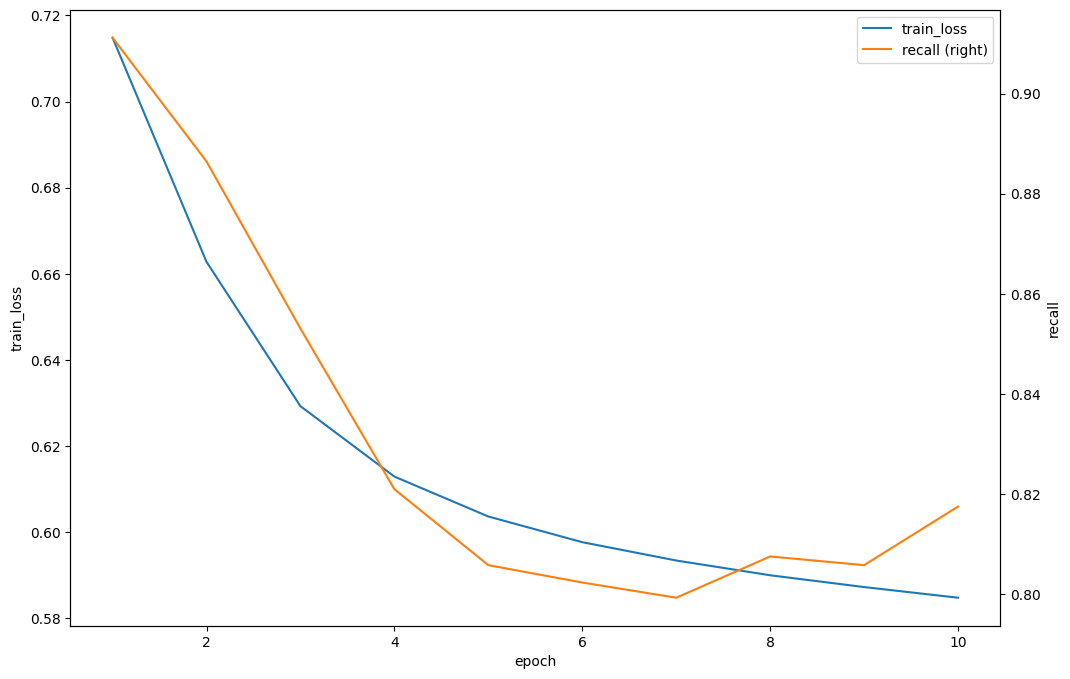

In [11]:
ax = training_history.plot(x="epoch", y="train_loss", figsize=(12, 8), color="tab:blue")
training_history.plot(
    x="epoch",
    y="recall",
    secondary_y=True,
    ax=ax,
    color="tab:orange",
)

ax.set_ylabel("train_loss")
ax.right_ax.set_ylabel("recall");

# Exercise: Discover Neural Network Architectures

We have a very basic neural network to determine if someone is earning more than $50k, but we can improve the performance of the basic model by change the architecture of the model. Your goal is to improve the predictive performance of this model by experimenting with the network architecture. You are free to modify the model, but keep the data used in the model the same.

### What you can change
Try different architectural choices such as:
- Depth; Adding or removing layers
- Width; Increase or decrease the number of neurons per layer
- Activation functions; Replace ReLU with alternatives (e.g., LeakyReLU, Tanh)
- Regularization: Add dropout layers, use batch normalization
- Output layer behavior; How do we convert the result to 0, 1

When adjusting the network, always also note down how many parameters the network has. Train and evaluate on the same dataset split. As the dataset is very unbalanced we are most interested in having a good recall. Track your results and identify which architectural choice led to improvements.

### Questions to answer
- Which architectural changes had the largest positive impact on performance?
- Did increasing model complexity always improve performance?
- Did you observe signs of overfitting? How did you address them?
- How does your improved model compare to:
- - The baseline model
- - The 10-feature model from the XAI exercise

### Optional bonus (advanced)

- Perform a systematic search (e.g., small grid search over depth/width)
- Compare with a tree-based model (e.g., XGBoost) from the previous exercises
- Reflect on whether the more complex neural network is actually worth it 

## Solution: Architecture Search Focused on Recall

This solution keeps the same dataset split and improves model design/training while prioritizing recall.

Workflow:
1. Build flexible architectures (depth/width/activation/dropout/batch norm)
2. Train with `BCEWithLogitsLoss` and class weighting (`pos_weight`) for imbalance
3. Compare baseline vs multiple improved architectures
4. Summarize findings for the exercise questions

In [12]:
# Flexible architecture builder

def build_model(input_size, hidden_sizes=(64, 32), dropout=0.2, activation="relu", batch_norm=True):
    activation_factories = {
        "relu": nn.ReLU,
        "leaky_relu": lambda: nn.LeakyReLU(negative_slope=0.1),
        "tanh": nn.Tanh,
    }

    if activation not in activation_factories:
        raise ValueError(f"Unsupported activation '{activation}'. Choose from {list(activation_factories)}")

    layers = []
    in_features = input_size
    for hidden_size in hidden_sizes:
        layers.append(nn.Linear(in_features, hidden_size))
        if batch_norm:
            layers.append(nn.BatchNorm1d(hidden_size))
        layers.append(activation_factories[activation]())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_features = hidden_size

    # Output logits (no final sigmoid). We apply sigmoid only for metric computation.
    layers.append(nn.Linear(in_features, 1))
    return nn.Sequential(*layers)


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

In [13]:
def evaluate_logits_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            logits = model(features)
            probabilities = torch.sigmoid(logits)
            all_probabilities.append(probabilities.cpu())
            all_targets.append(targets.cpu())

    y_true = torch.cat(all_targets).squeeze(1).numpy()
    y_prob = torch.cat(all_probabilities).squeeze(1).numpy()
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def train_logits_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=20,
    learning_rate=1e-3,
    pos_weight=None,
    patience=4,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device) if pos_weight is not None else None)

    best_recall = -1.0
    best_state = None
    no_improve_epochs = 0
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(features)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * features.size(0)

        validation_metrics = evaluate_logits_model(model, val_loader, device)
        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": running_loss / len(train_loader.dataset),
                **validation_metrics,
            }
        )

        if validation_metrics["recall"] > best_recall:
            best_recall = validation_metrics["recall"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [14]:
# Baseline evaluation from the previously trained BasicNN model
baseline_val_metrics = evaluate_model(trained_model, val_loader, device)
baseline_test_metrics = evaluate_model(trained_model, test_loader, device)

pd.DataFrame(
    [
        {"model": "baseline_basicnn", "split": "validation", **baseline_val_metrics},
        {"model": "baseline_basicnn", "split": "test", **baseline_test_metrics},
    ]
)

,model,split,accuracy,precision,recall,f1
0,baseline_basicnn,validation,0.852419,0.269969,0.817512,0.405897
1,baseline_basicnn,test,0.851576,0.283795,0.823386,0.422104


In [15]:
# Architecture search (same data split, improved model/training choices)

positive_count = train_y_tensor.sum().item()
negative_count = len(train_y_tensor) - positive_count
pos_weight = torch.tensor([negative_count / max(positive_count, 1.0)], dtype=torch.float32)

search_space = [
    {"name": "wide_relu", "hidden_sizes": (128, 64), "dropout": 0.2, "activation": "relu", "batch_norm": True, "lr": 1e-3, "epochs": 20},
    {"name": "deep_relu", "hidden_sizes": (128, 64, 32), "dropout": 0.25, "activation": "relu", "batch_norm": True, "lr": 1e-3, "epochs": 24},
    {"name": "leaky_medium", "hidden_sizes": (96, 48), "dropout": 0.15, "activation": "leaky_relu", "batch_norm": True, "lr": 1.2e-3, "epochs": 20},
    {"name": "tanh_regularized", "hidden_sizes": (128, 64), "dropout": 0.35, "activation": "tanh", "batch_norm": False, "lr": 8e-4, "epochs": 24},
]

experiment_rows = []
model_store = {}

for config in search_space:
    torch.manual_seed(99)
    candidate_model = build_model(
        input_size=train_x_tensor.shape[1],
        hidden_sizes=config["hidden_sizes"],
        dropout=config["dropout"],
        activation=config["activation"],
        batch_norm=config["batch_norm"],
    ).to(device)

    trained_candidate, candidate_history = train_logits_model(
        candidate_model,
        train_loader,
        val_loader,
        device,
        epochs=config["epochs"],
        learning_rate=config["lr"],
        pos_weight=pos_weight,
        patience=5,
    )

    val_metrics = evaluate_logits_model(trained_candidate, val_loader, device)
    test_metrics = evaluate_logits_model(trained_candidate, test_loader, device)

    experiment_rows.append(
        {
            "name": config["name"],
            "hidden_sizes": str(config["hidden_sizes"]),
            "dropout": config["dropout"],
            "activation": config["activation"],
            "batch_norm": config["batch_norm"],
            "params": count_trainable_parameters(trained_candidate),
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_precision": val_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_precision": test_metrics["precision"],
        }
    )

    model_store[config["name"]] = {
        "model": trained_candidate,
        "history": candidate_history,
        "config": config,
    }

results_df = (
    pd.DataFrame(experiment_rows)
    .sort_values(["val_recall", "val_f1", "val_precision"], ascending=False)
    .reset_index(drop=True)
)

results_df

,name,hidden_sizes,dropout,activation,batch_norm,params,val_recall,val_f1,val_precision,test_recall,test_f1,test_precision
0,deep_relu,"(128, 64, 32)",0.25,relu,True,27073,0.914174,0.299723,0.179245,0.922046,0.313913,0.189155
1,wide_relu,"(128, 64)",0.20,relu,True,24961,0.910707,0.349613,0.216330,0.914738,0.362452,0.226001
2,tanh_regularized,"(128, 64)",0.35,tanh,False,24577,0.905072,0.359876,0.224589,0.907430,0.371201,0.233323
3,leaky_medium,"(96, 48)",0.15,leaky_relu,True,17185,0.903338,0.362750,0.226941,0.903776,0.376363,0.237668


,model,parameters,val_recall,val_f1,test_recall,test_f1
0,baseline_basicnn,641,0.817512,0.405897,0.823386,0.422104
1,improved_leaky_medium,27073,0.903338,0.362750,0.903776,0.376363


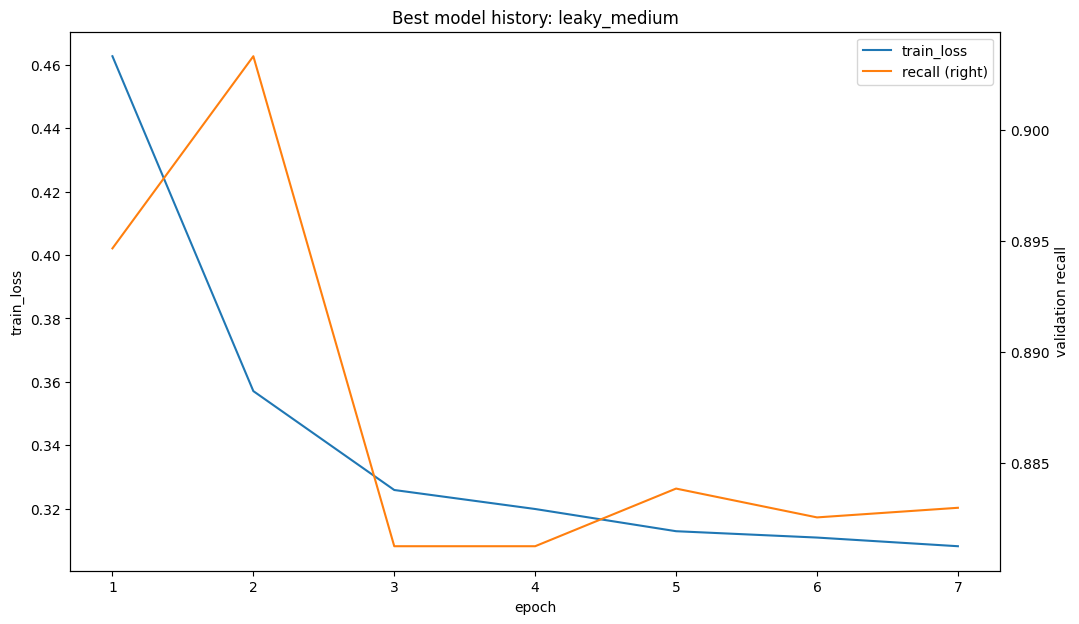

In [19]:
# Compare best architecture against baseline and inspect its training curve
best_model_name = results_df.iloc[3]["name"]
best_model_payload = model_store[best_model_name]
best_history_df = best_model_payload["history"]

best_val_metrics = evaluate_logits_model(best_model_payload["model"], val_loader, device)
best_test_metrics = evaluate_logits_model(best_model_payload["model"], test_loader, device)

comparison_df = pd.DataFrame(
    [
        {
            "model": "baseline_basicnn",
            "parameters": count_trainable_parameters(trained_model),
            "val_recall": baseline_val_metrics["recall"],
            "val_f1": baseline_val_metrics["f1"],
            "test_recall": baseline_test_metrics["recall"],
            "test_f1": baseline_test_metrics["f1"],
        },
        {
            "model": f"improved_{best_model_name}",
            "parameters": int(results_df.iloc[0]["params"]),
            "val_recall": best_val_metrics["recall"],
            "val_f1": best_val_metrics["f1"],
            "test_recall": best_test_metrics["recall"],
            "test_f1": best_test_metrics["f1"],
        },
    ]
)

ax = best_history_df.plot(x="epoch", y="train_loss", figsize=(12, 7), color="tab:blue", title=f"Best model history: {best_model_name}")
best_history_df.plot(x="epoch", y="recall", secondary_y=True, ax=ax, color="tab:orange")
ax.set_ylabel("train_loss")
ax.right_ax.set_ylabel("validation recall")

comparison_df

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# Use best architecture if available, otherwise fallback to baseline model
model_to_evaluate = best_model_payload["model"] if "best_model_payload" in globals() else trained_model
data_loader = test_loader  # change to val_loader if needed

model_to_evaluate.eval()
all_targets, all_preds = [], []

with torch.no_grad():
    for features, targets in data_loader:
        features = features.to(device)
        outputs = model_to_evaluate(features).detach().cpu().squeeze(1)

        # Handle both probability-output models and logit-output models
        if outputs.min() < 0 or outputs.max() > 1:
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs >= 0.5).int()

        all_targets.append(targets.cpu().squeeze(1).int())
        all_preds.append(preds)

y_true = torch.cat(all_targets).numpy()
y_pred = torch.cat(all_preds).numpy()

print(classification_report(y_true, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0     0.9915    0.7957    0.8829     11650
           1     0.2377    0.9038    0.3764       821

    accuracy                         0.8028     12471
   macro avg     0.6146    0.8497    0.6296     12471
weighted avg     0.9419    0.8028    0.8496     12471

Confusion matrix:
[[9270 2380]
 [  79  742]]
